In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
credit_wise = pd.read_csv("loan_approval_data.csv")
credit_wise.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# Handling Missing Values

In [3]:
from sklearn.impute import SimpleImputer
categorical_cols = credit_wise.select_dtypes(include = ['object']).columns
numerical_cols = credit_wise.select_dtypes(include = ["number"]).columns 
categorical_cols

#for filling numerical missing value
num_imp = SimpleImputer(strategy ="mean")
credit_wise[numerical_cols] = num_imp.fit_transform(credit_wise[numerical_cols])


#for filling categorical missing value
cat_imp = SimpleImputer(strategy = "most_frequent")
credit_wise[categorical_cols] = cat_imp.fit_transform(credit_wise[categorical_cols])


# Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Is Loan approved or not?')

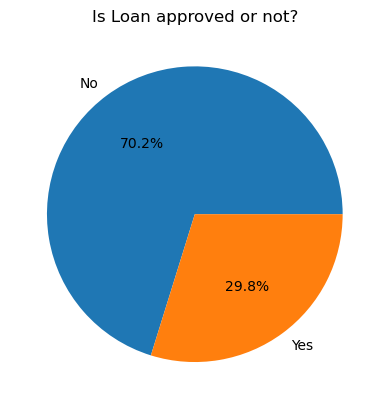

In [4]:
# checking How balanced our classes are:-
classes_count = credit_wise["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct = "%1.1f%%")
plt.title("Is Loan approved or not?")

In [5]:
#analysing categories for single category to check seperately
# gender_count = credit_wise["Gender"].value_counts()
# ax = sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

# Education_level_count = credit_wise["Education_Level"].value_counts()
# ax = sns.barplot(Education_level_count)
# ax.bar_label(ax.containers[0])

# Employment_Status_count = credit_wise["Employment_Status"].value_counts()
# ax = sns.barplot(Employment_Status_count)
# ax.bar_label(ax.containers[0])

# Marital_Status_count = credit_wise["Marital_Status"].value_counts()
# ax = sns.barplot(Marital_Status_count)
# ax.bar_label(ax.containers[0])

# Employer_Category_count = credit_wise["Employer_Category"].value_counts()
# ax = sns.barplot(Employer_Category_count)
# ax.bar_label(ax.containers[0])

# Property_Area_count = credit_wise["Property_Area"].value_counts()
# ax = sns.barplot(Property_Area_count)
# ax.bar_label(ax.containers[0])

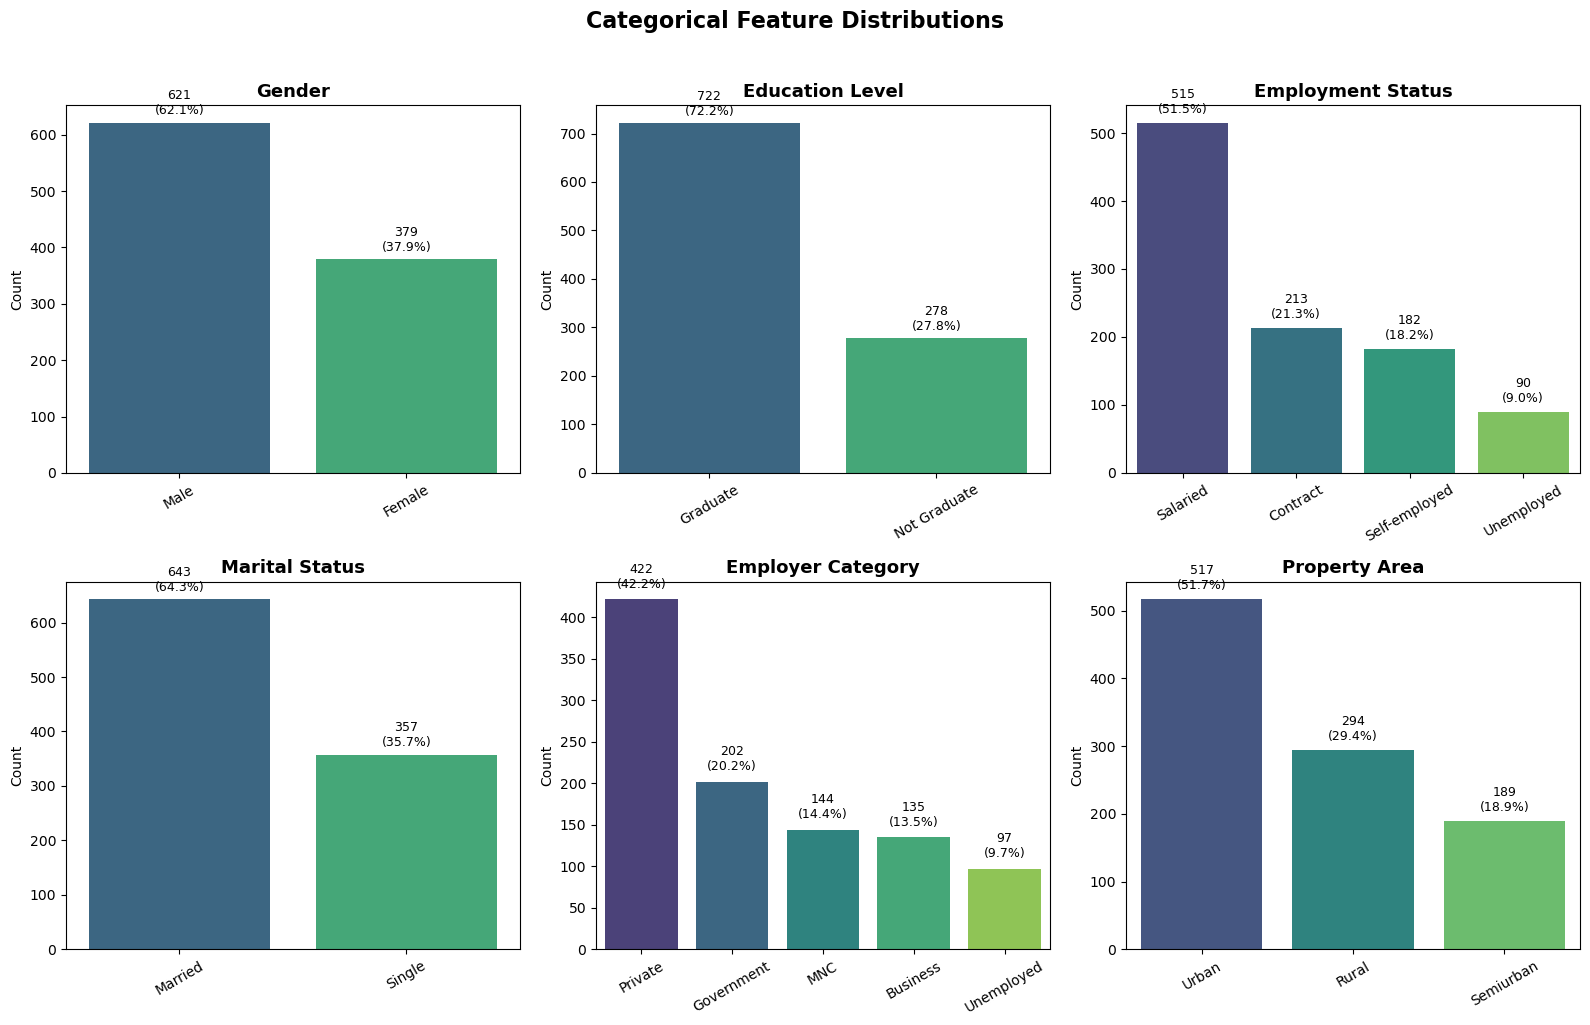

In [6]:
#analysing multiple category at same time
cols = ["Gender", "Education_Level", "Employment_Status",
        "Marital_Status", "Employer_Category", "Property_Area"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    counts = credit_wise[col].value_counts().reset_index()
    counts.columns = ["Category", "Count"]

    sns.barplot(
        data=counts,
        x="Category",
        y="Count",
        hue="Category",        # fixes the FutureWarning
        palette="viridis",
        legend=False,          # hides the redundant legend
        ax=ax
    )

    ax.set_title(col.replace("_", " "), fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

    # Show count + percentage on each bar
    total = counts["Count"].sum()
    for container in ax.containers:
        for bar in container:
            height = int(bar.get_height())
            pct = height / total * 100
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + total * 0.01,
                f"{height}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=9
            )

plt.suptitle("Categorical Feature Distributions", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

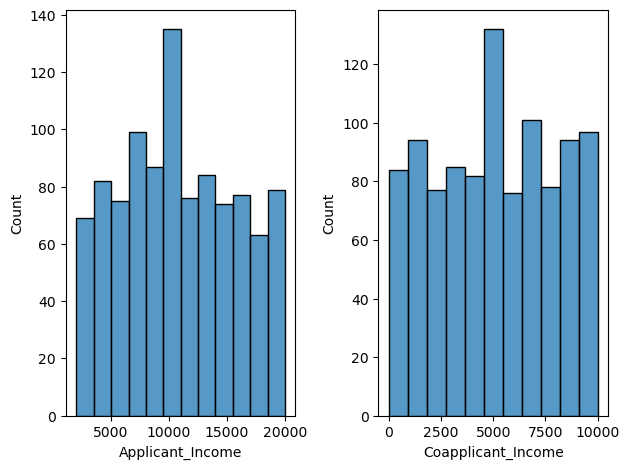

In [7]:
#analyzing income 
fig,axes = plt.subplots(1,2)
sns.histplot(ax =axes[0], data = credit_wise,x = "Applicant_Income")
sns.histplot(ax =axes[1], data = credit_wise,x = "Coapplicant_Income")
plt.tight_layout()

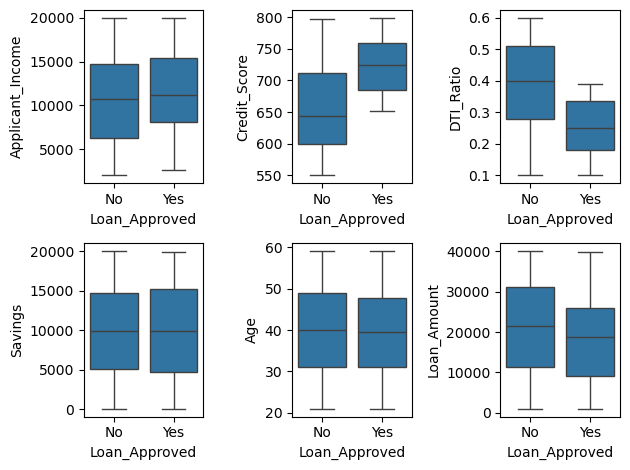

In [8]:
#analysing outlier for our numerical cols
fig,axes = plt.subplots(2,3)
sns.boxplot(ax =axes[0,0],data = credit_wise,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax =axes[0,1],data = credit_wise,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax =axes[0,2],data = credit_wise,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax =axes[1,0],data = credit_wise,x="Loan_Approved",y="Savings")
sns.boxplot(ax =axes[1,1],data = credit_wise,x="Loan_Approved",y="Age")
sns.boxplot(ax =axes[1,2],data = credit_wise,x="Loan_Approved",y="Loan_Amount")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

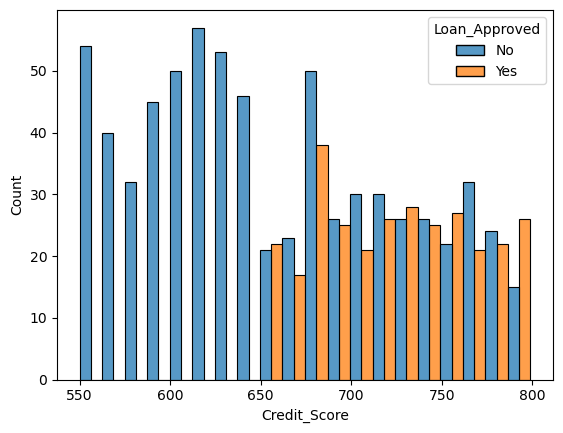

In [10]:
#relationship between credit_score and loan aprroval
sns.histplot(
    data = credit_wise,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

In [12]:
#remove Applicant id cause its an unnecessary feature
credit_wise = credit_wise.drop("Applicant_ID",axis = 1)
credit_wise

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes
